In [60]:
import pyvista
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Get data from OF

In [61]:
points = np.arange(0.01, 0.2, 0.01)

pyVista_res_l2 = pd.DataFrame()
pyVista_res_l2['points'] = points
pyVista_res_l2.set_index('points', inplace = True)

pyVista_sum_l2 = pd.DataFrame()
pyVista_sum_l2['points'] = points
pyVista_sum_l2.set_index('points', inplace = True)

In [62]:
#how we getting 3ed column of velocity field
#mesh['U'][:,-1]

In [67]:
def get_sample_data(path):
    filename = path + '.vtk'
    mesh = pyvista.read(filename)
    mesh.sample_over_line((0, -0.00227, 0.09),(0, 0.00227, 0.09))
    sample = [] 
    for i in points:
         sample.append(mesh.sample_over_line((0, -0.00227, i),(0, 0.00227, i), resolution=31)['U'].max())#resolution=15
    sums=[] 
    for i in points:
         sums.append(mesh.sample_over_line((0, -0.00227, i),(0, 0.00227, i),resolution=31)['U'].sum())#resolution=15
    return sample, sums 

In [68]:
files = ['8k_cells','16k_cells','33k_cells','57k_cells','194k_cells','460k_cells','656k_cells']

#/home/asa/Desktop/OldReposOfFDA_collab/FDA-collaboration/verification/
for i in files:
    pyVista_res_l2[i], pyVista_sum_l2[i]  = get_sample_data('/home/asa/Desktop/OldReposOfFDA_collab/FDA-collaboration/verification/data/ri_extr/'+'channel_'+i)
    

In [69]:
pyVista_res_l2

,8k_cells,16k_cells,33k_cells,57k_cells,194k_cells,460k_cells,656k_cells
points,,,,,,,
0.01,0.833983,0.857267,0.858514,0.858210,0.856249,0.853754,0.852858
0.02,0.927907,0.959453,0.962818,0.968548,0.974652,0.976256,0.976632
0.03,0.968229,1.003221,1.007002,1.015465,1.024470,1.027603,1.028466
0.04,0.987044,1.023181,1.026888,1.036420,1.046448,1.050143,1.051190
0.05,0.996125,1.032448,1.036061,1.046034,1.056416,1.060324,1.061436
0.06,1.000579,1.036838,1.040363,1.050504,1.061003,1.064987,1.066127
0.07,1.002782,1.038920,1.042384,1.052596,1.063123,1.067139,1.068287
0.08,1.003874,1.039917,1.043342,1.053580,1.064108,1.068134,1.069285
0.09,1.004420,1.040386,1.043794,1.054038,1.064566,1.068594,1.069750


In [66]:
pyVista_sum_l2

,8k_cells,16k_cells,33k_cells,57k_cells,194k_cells,460k_cells,656k_cells
points,,,,,,,
0.01,12.786933,13.321697,13.423883,13.476892,13.570235,13.599047,13.609884
0.02,13.399434,13.956957,14.052597,14.150199,14.277113,14.328041,14.343075
0.03,13.654453,14.216593,14.307219,14.422493,14.559353,14.617373,14.633655
0.04,13.771320,14.333111,14.420064,14.542368,14.682255,14.742743,14.759392
0.05,13.827271,14.386937,14.471878,14.597176,14.737808,14.799208,14.815947
0.06,13.854630,14.412401,14.496137,14.622614,14.763343,14.825041,14.841805
0.07,13.868151,14.424459,14.507532,14.634529,14.775161,14.836964,14.853714
0.08,13.874843,14.430235,14.512926,14.640110,14.780636,14.842461,14.859224
0.09,13.878190,14.432961,14.515475,14.642731,14.783191,14.845020,14.861773


## Analytical solution

In [8]:
#radius
R = 0.00227 
#density
rho = 1.0
v = 0.5216
#Reynolds number
Re = rho*v*R*2/(1.48e-05)
print(Re)

160.0043243243243


In [9]:
length = 0.5
#friction factor
f = 64/Re
dP = f*length*1*v**2/(2*R*2)
pressureGrad = dP/length
dPdx = 1.48e-05*4/(R**2)
print('f = {:2.4}, Pressure Gradient = {:2.8}, dpdx = {:2.8}'.format(f, pressureGrad, dPdx))

f = 0.4, Pressure Gradient = 11.984987, dpdx = 11.488676


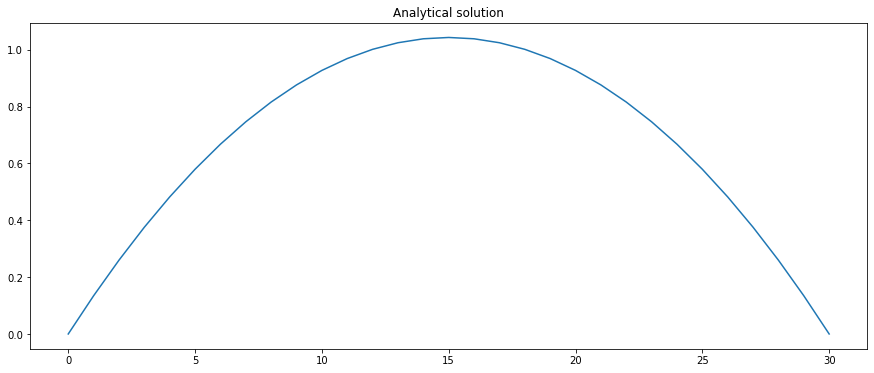

In [54]:
plt.figure(figsize=(15,6))
r1 = np.linspace(-0.00227,0.00227,31)#,1000)
r = np.sqrt(r1**2)  # array how radius changing
analytical_solution = (R**2-r**2)*(1/(4*1.48e-05))*pressureGrad 
plt.title('Analytical solution')
plt.plot(analytical_solution);

In [11]:
analytical_solution.max()

1.0431999999999997

In [42]:
pyVista_res_l2.tail(1)

,8k_cells,16k_cells,32k_cells,57k_cells,194k_cells,460k_cells,656k_cells
points,,,,,,,
0.19,1.01415,1.04717,1.05061,1.05928,1.06821,1.07143,1.07231


In [12]:
v_max = v*2
v_max

1.0432

# Gather plot data

In [14]:
plots = []

#files = ['16k_cells','57k_cells','194k_cells','460k_cells','656k_cells']
for i in files: 
    filename = '/home/asa/Desktop/OldReposOfFDA_collab/FDA-collaboration/verification/data/ri_extr/channel_'+i+'.vtk'
    mesh = pyvista.read(filename)

    plots.append(mesh.sample_over_line((0, -0.00227, 0.15),(0, 0.00227, 0.015),resolution = 30)['U'][:,-1])


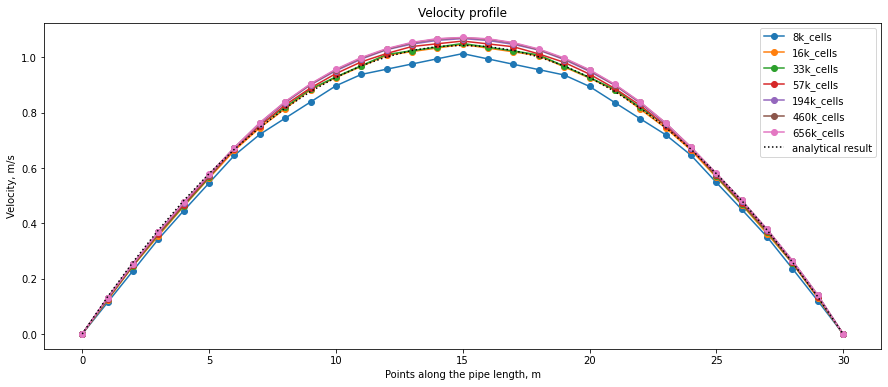

In [73]:
plt.figure(figsize=(15,6))
x = np.linspace(0,30,1000)

for i in range(0,len(files)):
    
    plt.plot(plots[i], label = files[i], marker = 'o')
    
plt.plot(analytical_solution, label = 'analytical result', color = 'black', linestyle = ':')
plt.legend(loc="upper right")
plt.xlabel('Points in the profile, m')
plt.ylabel('Velocity, m/s')
plt.title('Velocity profile');

In [16]:
import math
length = 0.2
pi = math.pi

In [17]:
V_cyl = pi*length*(R**2) # cylindre volume
V_cyl 

3.2376625569365686e-06

In [18]:
V_cyl/460800

7.026177423907484e-12

In [19]:
V_cyl/57600

5.6209419391259874e-11

In [20]:
V_cyl/16200

1.998557133911462e-10

In [46]:
n_el = np.array([8000, 16000, 33000, 57600, 194400, 460000, 656000]) # number of elements for each mesh
A_omega = np.ones((len(n_el)))*V_cyl
h = np.sqrt(A_omega/n_el) 
h

array([2.01173512e-05, 1.42251155e-05, 9.90509902e-06, 7.49729414e-06,
       4.08101002e-06, 2.65299771e-06, 2.22158979e-06])

In [22]:
h[2]/h[1]

0.5270462766947299

In [23]:
error = pyVista_res_l2 - analytical_solution.max()

In [43]:
mesh_errors = pd.DataFrame()
mesh_errors['1'] = np.abs(pyVista_res_l2['16k_cells'] - pyVista_res_l2['8k_cells'])
mesh_errors['2'] = np.abs(pyVista_res_l2['32k_cells'] - pyVista_res_l2['16k_cells'])
mesh_errors['3'] = np.abs(pyVista_res_l2['57k_cells'] - pyVista_res_l2['32k_cells'])
mesh_errors['4'] = np.abs(pyVista_res_l2['194k_cells'] - pyVista_res_l2['57k_cells'])
mesh_errors['5'] = np.abs(pyVista_res_l2['460k_cells'] - pyVista_res_l2['194k_cells'])
mesh_errors['6'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['460k_cells'])
mesh_errors.tail()

,1,2,3,4,5,6
points,,,,,,
0.15,0.033020,0.00344,0.00868,0.00892,0.00322,0.00089
0.16,0.033025,0.00344,0.00867,0.00892,0.00323,0.00088
0.17,0.033020,0.00344,0.00867,0.00893,0.00322,0.00088
0.18,0.033020,0.00344,0.00867,0.00893,0.00322,0.00088
0.19,0.033020,0.00344,0.00867,0.00893,0.00322,0.00088


In [25]:
element = pyVista_res_l2['57k_cells'][0.19]

norm = []
for i in range(0,len(files)):
    l2 = np.sqrt(np.sum(((plots[i]-analytical_solution)**2)))
    print('l2 norm for', files[i],'is:',round(l2,8))
    norm.append(l2)

l2 norm for 8k_cells is: 0.18537437
l2 norm for 16k_cells is: 0.04868362
l2 norm for 32k_cells is: 0.04312301
l2 norm for 57k_cells is: 0.05638754
l2 norm for 194k_cells is: 0.09222755
l2 norm for 460k_cells is: 0.1052424
l2 norm for 656k_cells is: 0.11180504


In [44]:
element = pyVista_res_l2['57k_cells'][0.19]

norm_abs = []
for i in range(0,len(files)):
    l2 = np.sqrt(np.sum(((plots[i]-analytical_solution)**2)))/(len(plots[i]))
    print('l2 norm for', files[i],'is:',round(l2,8))
    norm_abs.append(l2)

l2 norm for 8k_cells is: 0.00597982
l2 norm for 16k_cells is: 0.00157044
l2 norm for 32k_cells is: 0.00139106
l2 norm for 57k_cells is: 0.00181895
l2 norm for 194k_cells is: 0.00297508
l2 norm for 460k_cells is: 0.00339492
l2 norm for 656k_cells is: 0.00360661


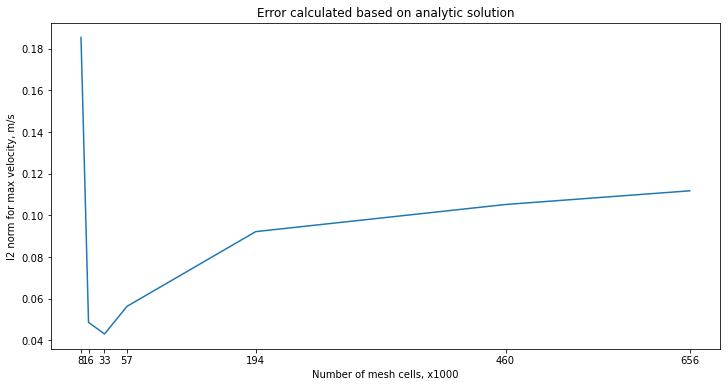

In [50]:
plt.figure(figsize=(12,6))
plt.plot([8,16,33,57,194,460,656],norm)
plt.xlabel('Number of mesh cells, x1000')
plt.ylabel('l2 norm for max velocity, m/s')
plt.title('Error calculated based on analytic solution')
plt.xticks([8,16,33,57,194,460,656], ['8','16','33','57','194', '460','656']);
#fig.set_xticklabels([8,16,57,194,460,656]);

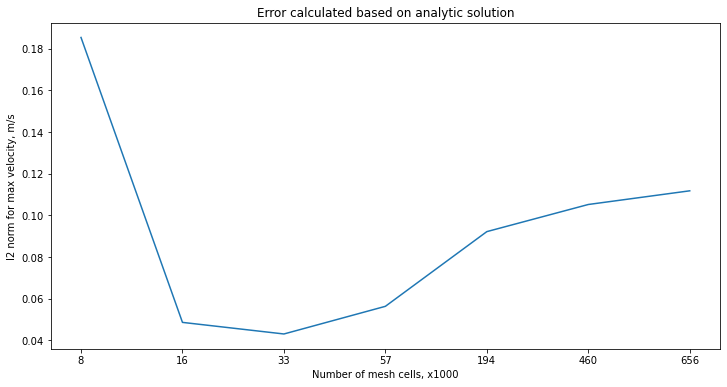

In [49]:
plt.figure(figsize=(12,6))
plt.plot(norm)
plt.xlabel('Number of mesh cells, x1000')
plt.ylabel('l2 norm for max velocity, m/s')
plt.title('Error calculated based on analytic solution')
plt.xticks([0,1,2,3,4,5,6], ['8','16','33','57','194', '460','656']);
#fig.set_xticklabels([8,16,57,194,460,656]);

# From the plot data we could see that there is no convergence.

In [33]:
max_error = pd.DataFrame()
max_error['1'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['8k_cells'])
max_error['2'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['16k_cells'])
max_error['3'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['32k_cells'])
max_error['4'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['57k_cells'])
max_error['5'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['194k_cells'])
max_error['6'] = np.abs(pyVista_res_l2['656k_cells'] - pyVista_res_l2['460k_cells'])
max_error.tail()

,1,2,3,4,5,6
points,,,,,,
0.15,0.058170,0.02515,0.02171,0.01303,0.00411,0.00089
0.16,0.058165,0.02514,0.02170,0.01303,0.00411,0.00088
0.17,0.058160,0.02514,0.02170,0.01303,0.00410,0.00088
0.18,0.058160,0.02514,0.02170,0.01303,0.00410,0.00088
0.19,0.058160,0.02514,0.02170,0.01303,0.00410,0.00088


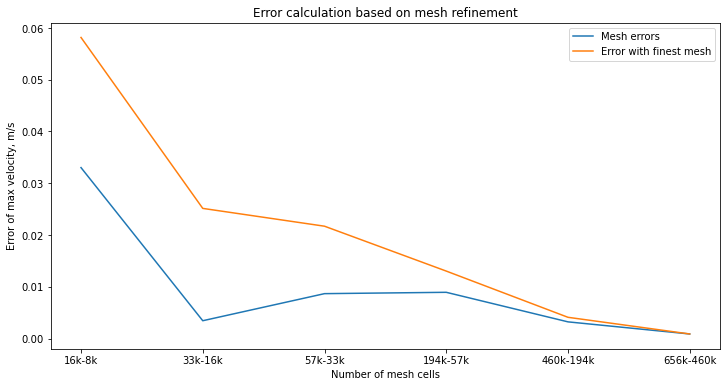

In [51]:
plt.figure(figsize=(12,6))
plt.plot(mesh_errors.loc[0.19],label = 'Mesh errors')
plt.xlabel('Number of mesh cells')
plt.plot(max_error.loc[0.19],label = 'Error with finest mesh')
plt.ylabel('Error of max velocity, m/s')
plt.title('Error calculation based on mesh refinement')
plt.legend();
plt.xticks([0, 1, 2,3,4,5], ['16k-8k','33k-16k','57k-33k','194k-57k', '460k-194k','656k-460k']);

In [37]:
norm2 = []
for i in range(0,len(files)):
    l2 = np.abs(max(plots[i])-max(analytical_solution))
    print('difference between max analitical solution and computational result', files[i],'is:',round (l2,8), 'm/s')
    norm2.append(l2)

difference between max analitical solution and computational result 8k_cells is: 0.02999876 m/s
difference between max analitical solution and computational result 16k_cells is: 0.00318994 m/s
difference between max analitical solution and computational result 32k_cells is: 0.00667061 m/s
difference between max analitical solution and computational result 57k_cells is: 0.01533999 m/s
difference between max analitical solution and computational result 194k_cells is: 0.02428557 m/s
difference between max analitical solution and computational result 460k_cells is: 0.02751006 m/s
difference between max analitical solution and computational result 656k_cells is: 0.0283965 m/s


In [39]:
abs_err = []
for i in range(0,len(files)):
    err = np.sum(np.abs(max(plots[i])-max(analytical_solution)))/(len(plots[i]))
    print('mean absolute error', files[i],'is:',round (err,8), 'm/s')
    abs_err.append(err)

difference between max analitical solution and computational result 8k_cells is: 0.0009677 m/s
difference between max analitical solution and computational result 16k_cells is: 0.0001029 m/s
difference between max analitical solution and computational result 32k_cells is: 0.00021518 m/s
difference between max analitical solution and computational result 57k_cells is: 0.00049484 m/s
difference between max analitical solution and computational result 194k_cells is: 0.00078341 m/s
difference between max analitical solution and computational result 460k_cells is: 0.00088742 m/s
difference between max analitical solution and computational result 656k_cells is: 0.00091602 m/s


In [40]:
plots[0]

array([ 8.1247175e-17,  1.1417262e-01,  2.2834584e-01,  3.4251973e-01,
        4.4549564e-01,  5.4558593e-01,  6.4567512e-01,  7.2125483e-01,
        7.7981973e-01,  8.3837146e-01,  8.9690328e-01,  9.3797374e-01,
        9.5687389e-01,  9.7573125e-01,  9.9451578e-01,  1.0132012e+00,
        9.9396360e-01,  9.7467792e-01,  9.5534915e-01,  9.3597513e-01,
        8.9458776e-01,  8.3603019e-01,  7.7783006e-01,  7.2024667e-01,
        6.4611608e-01,  5.4761833e-01,  4.5031440e-01,  3.5092965e-01,
        2.3626649e-01,  1.1990536e-01, -3.4934241e-16], dtype=float32)

In [70]:
analytical_solution

array([0.        , 0.13445689, 0.25964089, 0.375552  , 0.48219022,
       0.57955556, 0.667648  , 0.74646756, 0.81601422, 0.876288  ,
       0.92728889, 0.96901689, 1.001472  , 1.02465422, 1.03856356,
       1.0432    , 1.03856356, 1.02465422, 1.001472  , 0.96901689,
       0.92728889, 0.876288  , 0.81601422, 0.74646756, 0.667648  ,
       0.57955556, 0.48219022, 0.375552  , 0.25964089, 0.13445689,
       0.        ])